# Step 1 — Decide Which Features to Keep

Features to exclude (for now):
- `key` — ordinal encoding of a circular quantity (0–11) is misleading for distance; skip unless you later use circular encoding
- `time_signature` — rarely meaningful for mood
- `duration_ms` — not a mood characteristic
- `popularity` — could bias results, better used as a re-ranking signal later

We will start with the core set per below:

In [2]:
audio_features = [
    'valence',
    'energy',
    'danceability',
    'acousticness',
    'instrumentalness',
    'speechiness',
    'loudness',
    'tempo',
    'liveness',
    'mode'          # binary, but still informative
]

# Step 2 — Handle Skewed Features with Log Transform

For elements such as `instrumentalness` and `speechiness` that are heavily right-skewed, we transform them into logs via `np.log1()` to make it easier for ML processing. (e.g. managing logs of 10.31, 10.60, 10.82, 11.51... is easier than 30k, 40k, 50k, 100k)

Why log1p? A value of 0 would cause `log(0) = -inf`. Using `log(1+x)` maps 0 → 0 safely.

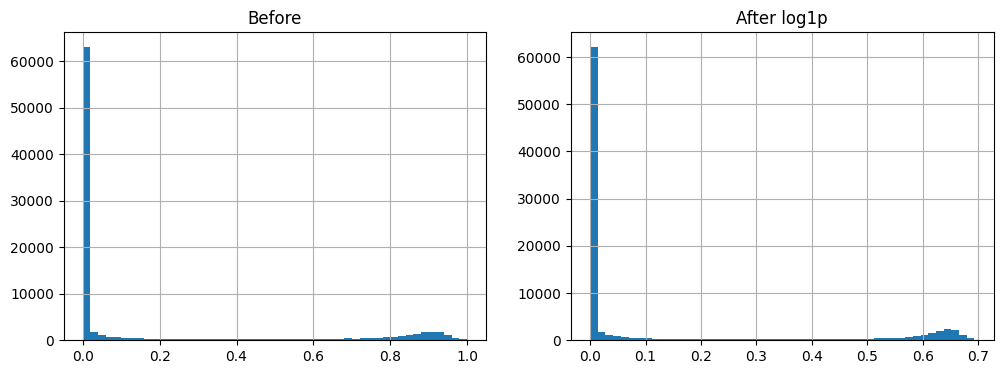

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/tracks_clean.csv')

# Log1p transform (log(1+x)) — safe for values that include 0
df['instrumentalness_log'] = np.log1p(df['instrumentalness'])
df['speechiness_log'] = np.log1p(df['speechiness'])

fig, axes = plt.subplots(1,2, figsize=(12, 4))
df['instrumentalness'].hist(bins=50, ax=axes[0])
axes[0].set_title('Before')

df['instrumentalness_log'].hist(bins=50, ax=axes[1])
axes[1].set_title('After log1p')
plt.show()

# Step 3 — Normalize Features

We use `sklearn`’s `StandardScaler` (z-score standardization) to scale continuous features and save the fitted scaler as a `pickle` for later use.

We standardize features because they have different ranges (e.g., tempo ranges from ~60–200, while loudness ranges from -60 to 0, and other features are between 0–1). Without scaling, large-range features would dominate distance-based models.

`StandardScaler` computes the mean and standard deviation for each feature using `fit()`, then transforms each value using:

`z = (x - mean) / std`

`fit_transform()` performs both steps at once: it learns the statistics and immediately applies the transformation.

After scaling, each feature has mean ≈ 0 and standard deviation ≈ 1, making all features comparable for machine learning algorithms like clustering or similarity search.

In [5]:
from sklearn.preprocessing import StandardScaler

features_to_scale =[
    'valence', 'energy', 'danceability', 'acousticness',
    'instrumentalness_log', 'speechiness_log', 'loudness',
    'tempo', 'liveness', 'mode'
]

scalar = StandardScaler() # Create the scalar container
audio_matrix = scalar.fit_transform(df[features_to_scale]) # Fit the features to scale inside the container

print(f"Audio matrix shape: {audio_matrix.shape}")
print(f"Mean (should be ~0): {audio_matrix.mean(axis=0).round(3)}")
print(f"Std (should be ~1): {audio_matrix.std(axis=0).round(3)}")

import pickle
with open('../embeddings/scaler.pkl', 'wb') as f:
    pickle.dump(scalar, f) # Save the trained scalar container

Audio matrix shape: (89740, 10)
Mean (should be ~0): [-0. -0. -0. -0.  0.  0. -0. -0. -0.  0.]
Std (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Step 4 — Encode Genre

We use `sklearn`’s `LabelEncoder` encode metadata into numerical index (e.g. pop -> 7, rock -> 12...).

`LabelEncoder` is typically used to standardize metadata, while `StandardScaler` is used for numerical data.

Note: You will decide in Phase 4 whether to include genre as part of the FAISS vector or use it as a filter. For now, just encode it and save.

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['genre_encoded'] = le.fit_transform(df['track_genre'])

# Save label encoder
with open('../embeddings/genre_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print(f"Number of genres: {len(le.classes_)}")
print(le.classes_[:20])

Number of genres: 113
['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil' 'breakbeat' 'british'
 'cantopop' 'chicago-house' 'children' 'chill' 'classical' 'club' 'comedy'
 'country']


# Step 5 — Save the Audio Matrix

We save the processed audio_matrix` (output of `StandardScaler`) as a `.npy` file because it is a compact, fast-loading binary format optimized for machine learning tasks such as similarity search, clustering, and recommendation systems.

We also save the engineered DataFrame with `instrumentalness_log` and `speechiness_log` as a `.csv` file so that we can inspect the data, debug features, and access metadata (such as track names, artists, and genres) in a human-readable format.

In [13]:
np.save('../embeddings/audio_matrix.npy', audio_matrix)
df.to_csv('../data/processed/tracks_engineered.csv', index=False)

print(f"Saved audio_matrix.npy: shape {audio_matrix.shape}")

Saved audio_matrix.npy: shape (89740, 10)


# Step 6 — Visualize Feature Space with PCA

This is optional but illuminating, where we use PCA to see how similar or different is each genre to each other.

Note that PC1 captures the largest amount of variance in the dataset, while PC2 captures the second-largest amount. As a result, PC1 is often more informative, although both dimensions can reveal meaningful structure.

What to look for:
- Do genres cluster?
- Does pop occupy a different region than classical?
- Visible clustering suggests that the engineered audio features capture meaningful musical structure and may be useful for downstream tasks such as genre classification or recommendation.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # Instead of: [all 10 of audio features], you'd get PC1, PC2
coords_2d = pca.fit_transform(audio_matrix) # Learn the principal components and project every track from the original feature space into 2D NumPy array

import plotly.express as px
sample = df.sample(5000, random_state=42).copy() # Select 5K random rows from df (tracks_clean.csv) with a random seed of 42
sample_coords = pca.transform(audio_matrix[sample.index]) # Convert the sampled audio features into 2D PCA coordinates

fig = px.scatter(
    x=sample_coords[:,0], # Select PC1
    y=sample_coords[:,1], # Select PC2
    color=sample['track_genre'],
    hover_name=sample['track_name'],
    title='Track Feature Space (PCA 2D)',
    opacity=0.5
)
fig.show()